# SaaS Metrics Validation & Exploratory Analysis

## Purpose

This notebook validates the input data and business assumptions used to compute:

1. Monthly MRR
2. Monthly churned customers
3. 3-month cohort retention

The goal is to:
- Verify data integrity
- Validate business invariants
- Identify edge cases affecting metric implementation
- Document assumptions explicitly

# Business Metric Definitions

### 1. Monthly MRR
A subscription contributes to MRR for a calendar month if it is active at any point in that month.

### 2. Churn
A churn event occurs when:
- A subscription has an end_date
- AND no new subscription for the same customer starts within 30 days after that end_date

Churn is measured at the customer level.

### 3. 3-Month Retention
A customer is retained if they have an active subscription exactly 3 months after their signup_date.

## Open Clarifications
- Are end_date values inclusive or exclusive?
- Is 3 months defined as 90 days or calendar months?
- Do partial months count fully toward MRR?

## Clarifications & Assumptions Derived from Assignment Wording

The assignment does not explicitly define several boundary conditions in the metric definitions.  
To ensure consistent and defensible implementation, the following assumptions are made based on the wording and common SaaS analytics standards.

---

### 1. End Date Inclusivity

**Assignment wording:**
> “sum monthly_price of all subscriptions that are active in that month”

The assignment does not specify whether `end_date` is inclusive or exclusive.

**Assumption:**  
`end_date` is treated as **inclusive**.  
A subscription ending on 2024-01-31 is considered active through January 31.

**Reasoning:**
- The phrase “active in that month” implies activity during any part of the month.
- In most SaaS billing systems, subscriptions are active through the final billed day.
- Treating `end_date` as inclusive prevents unintentionally excluding valid revenue or retention events.

---

### 2. Monthly MRR Treatment of Partial Months

**Assignment wording:**
> “For each month, sum monthly_price of all subscriptions that are active in that month.”

The definition does not mention prorating revenue.

**Assumption:**  
If a subscription is active at any point during a calendar month, the full `monthly_price` is counted toward that month’s MRR.

**Reasoning:**
- The wording says “sum monthly_price,” not “sum prorated revenue.”
- No instruction is given to compute daily revenue.
- In simplified SaaS reporting exercises, MRR typically reflects contracted monthly value rather than prorated cash flow.
- Implementing proration would introduce complexity not requested in the assignment.

---

### 3. Churn Definition (30-Day Window)

**Assignment wording:**
> “A churn event is when a subscription has an end_date and the customer has no new subscription starting within 30 days after that end_date.”

The phrase “within 30 days” introduces a boundary condition ambiguity.

**Assumption:**  
- If the next subscription starts **≤ 30 days** after `end_date`, the customer is **not churned**.
- If the gap is **> 30 days**, the customer is considered churned.

Formally:
```
gap_days = next_start_date - end_date
churn occurs if gap_days > 30
```

**Reasoning:**
- The phrase “within 30 days” implies inclusion of the 30th day.
- Interpreting “within” as inclusive is consistent with common legal and business phrasing.
- This avoids incorrectly labeling customers who re-subscribe exactly 30 days later as churned.

---

### 4. Definition of “3 Months After Signup”

**Assignment wording:**
> “active 3 months after their signup date”

The assignment does not specify whether this means:
- Exactly 90 days, or
- Calendar month offset

**Assumption:**  
“3 months” is interpreted as a **calendar month offset**, implemented using: `signup_date + DateOffset(months=3)`

**Reasoning:**
- The wording uses “months,” not “90 days.”
- Calendar-based offsets are standard in cohort analysis.
- Using a fixed 90-day window would drift relative to calendar cohorts and complicate interpretation.

---

### 5. Churn Measured at Customer Level

**Assignment wording:**
> “Monthly churned customers count.”

**Assumption:**  
Churn is measured at the **customer level**, not the subscription level.

**Reasoning:**
- The metric explicitly refers to “customers,” not subscriptions.
- If a customer has multiple subscriptions historically, churn is counted only once per qualifying churn event.

---

## Summary

Where the assignment leaves room for interpretation, assumptions were made by:

1. Closely analyzing the wording,
2. Following standard SaaS metric conventions,
3. Choosing the simplest implementation consistent with the requirements,
4. Documenting each decision explicitly to ensure reproducibility.

These assumptions must be applied consistently throughout the implementation.

# 1. Load Data & Structural Validation

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

drive_mounted = os.path.isdir('/content/drive/MyDrive')

if drive_mounted:
    print("Google Drive is successfully mounted.")
else:
    print("Google Drive is NOT mounted. Please run the drive.mount() cell again.")

Google Drive is successfully mounted.


To prevent the ambiguities encountered with for example `NaT` values in the `end_date` column, and to ensure higher data quality for future analyses, the following best practices are recommended:

1.  **Implement Pre-conversion Validation on Raw Data**: Before converting string columns to dtype objects, implement a robust validation layer. This repo implement basic data validation and cleaning. Ensuring clean data for metric calculation

2.  **Distinguish Missing from Malformed Values Early**: If the original data source permits, differentiate between truly missing (e.g., empty string or `NULL`) and malformed date strings at the data ingestion stage. This metadata can be preserved in a separate flag column (e.g., `is_end_date_malformed`, `is_end_date_missing`).

3.  **Correct Data at Source**: The most effective long-term solution is to correct data quality issues at their origin. Work with data producers or source system administrators to improve data entry forms, enforce data types, and implement stricter validation rules in the systems where the data is first captured.

4.  **Document Data Assumptions and Anomalies**: Maintain clear documentation of data handling strategies, especially for edge cases like `NaT` values. Document assumptions made (e.g., all `NaT` in `end_date` are ongoing if not explicitly malformed) and log any identified data anomalies for future reference and remediation.

By adopting these practices, future analyses can proceed with higher confidence in the data's integrity, and the distinction between genuinely ongoing subscriptions and data entry errors can be made more explicitly and accurately.

In [3]:
import pandas as pd
import os

# Base path for your Google Drive files. Adjust if your files are in a subfolder.
# For example, if your files are in 'My Drive/data/', set base_path = '/content/drive/MyDrive/data/'
base_path = '/content/drive/MyDrive/Customer Project/'

customers = pd.read_csv(os.path.join(base_path, "customers_silver.csv"), parse_dates=["signup_date"])
subs = pd.read_csv(os.path.join(base_path, "subscriptions_silver.csv")) # Load without initial date parsing to handle manually

# Explicitly convert date columns with mixed format and error coercion
subs['start_date'] = pd.to_datetime(subs['start_date'], format='mixed', errors='coerce')
subs['end_date'] = pd.to_datetime(subs['end_date'], format='mixed', errors='coerce')

In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  38 non-null     object        
 1   signup_date  38 non-null     datetime64[ns]
 2   country      37 non-null     object        
dtypes: datetime64[ns](1), object(2)
memory usage: 1.0+ KB


In [5]:
subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    53 non-null     object        
 1   start_date     53 non-null     datetime64[ns]
 2   end_date       17 non-null     datetime64[ns]
 3   plan           53 non-null     object        
 4   monthly_price  53 non-null     int64         
dtypes: datetime64[ns](2), int64(1), object(2)
memory usage: 2.2+ KB


## 2. Structural & Data Integrity Validation

Before validating business rules, we validate the structural integrity of the dataset.

This includes:
- Required columns
- Missing values
- Data types
- Referential integrity
- Domain constraints

This avoids silent metric distortion where the invariant checks become misleading.

Example from input dataset:    
If `end_date` is missing due to bad parsing, you might think the subscription is active → artificially suppress churn.

### Assumed Validation Hierarchy

1. **Schema Validation**:    
Columns exist.

2. **Structural Integrity**:    
Missing values, type correctness, referential integrity.

3. **Domain Validation**:    
Ranges, allowed values, logical consistency.

4. **Business Invariant Validation**:    
Overlaps, churn gaps, retention logic.

5. **Metric-Specific Exploration**:    
Each layer assumes the previous layer is sound.

### 2.1 Required Columns

In [6]:
required_customer_cols = {"customer_id", "signup_date", "country"}
required_sub_cols = {"customer_id", "start_date", "end_date", "plan", "monthly_price"}

missing_customer_cols = required_customer_cols - set(customers.columns)
missing_sub_cols = required_sub_cols - set(subs.columns)

missing_customer_cols, missing_sub_cols

(set(), set())

If non-empty → hard failure.

In [7]:
assert required_customer_cols.issubset(customers.columns)
assert required_sub_cols.issubset(subs.columns)

#### Field Classification & Validation Strategy

To determine appropriate validation rules, fields are classified by their role in metric computation.

---

##### Customers Dataset

| Field        | Classification              | Reason |
|-------------|----------------------------|--------|
| customer_id | Computation-Critical       | Required for joins, churn, and retention |
| signup_date | Computation-Critical       | Required for cohort and 3-month retention |
| country     | Integrity-Monitoring       | Not used in required metrics but may indicate ingestion quality |

---

##### Subscriptions Dataset

| Field          | Classification              | Reason |
|---------------|----------------------------|--------|
| customer_id   | Computation-Critical       | Required for joins and churn grouping |
| start_date    | Computation-Critical       | Required for MRR, churn, and retention logic |
| end_date      | Business-Logic-Critical    | Required for churn and activity window evaluation (nullable allowed) |
| monthly_price | Computation-Critical       | Required for MRR calculation |
| plan          | Integrity-Monitoring       | Not required for metrics but useful for segmentation and anomaly detection |

---

### Validation Severity Strategy

- Computation-Critical → Validation errors (fail execution)
- Business-Logic-Critical → Strict validation (fail if malformed)
- Integrity-Monitoring → Log warnings
- Contextual → Monitor but do not block computation

### 2.2 Missing Value Analysis

Critical fields (cannot be null):
* For customers:
  * `customer_id`
  * `signup_date`

* For subscriptions:
  * `customer_id`
  * `start_date`
  * `monthly_price`

Allowed null:
* `end_date` (means active)

In [8]:
customers.isna().sum()

,0
customer_id,0
signup_date,0
country,1


In [9]:
assert customers['customer_id'].isnull().sum() == 0, "customer_id in customers DataFrame contains null values!"
assert customers['signup_date'].isnull().sum() == 0, "signup_date in customers DataFrame contains null values or NaT values!"

In [10]:
subs.isna().sum()

,0
customer_id,0
start_date,0
end_date,36
plan,0
monthly_price,0


In [11]:
assert subs['customer_id'].isnull().sum() == 0, "customer_id in subscriptions DataFrame contains null values!"
assert subs['start_date'].isnull().sum() == 0, "start_date in subscriptions DataFrame contains null values!"
assert subs['monthly_price'].isnull().sum() == 0, "monthly_price in subscriptions DataFrame contains null values!"

In [12]:
subs[subs["end_date"].isna()]

,customer_id,start_date,end_date,plan,monthly_price
1,C001,2024-04-01,NaT,pro,50
3,C002,2024-02-25,NaT,basic,25
7,C005,2024-02-28,NaT,basic,20
9,C006,2024-04-01,NaT,basic,20
11,C008,2024-03-22,NaT,basic,30
12,C009,2024-04-10,NaT,basic,25
14,C010,2024-05-01,NaT,basic,20
15,C011,2024-04-25,NaT,pro,50
17,C012,2024-06-15,NaT,basic,30
18,C013,2024-05-09,NaT,basic,25


If these exist → must decide:
* Drop rows?
* Raise error?
* Impute?

Document decision.

### 2.3 Date Type & Parsing Validation

Asserts on dates to check for malformed dates since these will also introduce NaT values:
* This affects churn
* This affects retention
* This affects MRR

In [19]:
print(f"'signup_date' column dtype: {customers['signup_date'].dtype}")
print(f"'start_date' column dtype: {subs['start_date'].dtype}")
print(f"'end_date' column dtype: {subs['end_date'].dtype}")

assert pd.api.types.is_datetime64_any_dtype(customers['signup_date']), "'signup_date' column in customers DataFrame is not datetime type!"
assert pd.api.types.is_datetime64_any_dtype(subs['start_date']), "'start_date' column in subs DataFrame is not datetime type!"
assert pd.api.types.is_datetime64_any_dtype(subs['end_date']), "'end_date' column in subs DataFrame is not datetime type!"

print("All specified date columns are correctly identified as datetime types.")

'signup_date' column dtype: datetime64[ns]
'start_date' column dtype: datetime64[ns]
'end_date' column dtype: datetime64[ns]
All specified date columns are correctly identified as datetime types.


If these display `datetime64[ns]` (or similar), it means `pd.to_datetime` successfully converted the values, and any malformed dates were coerced to `NaT`.

If, for some reason, a column still showed `object` dtype *after* trying to convert it to datetime, it would suggest a more severe problem where pandas couldn't interpret any of the values as dates, or the conversion wasn't applied correctly. In such a rare case, you would then manually inspect the unique non-NaT values in that column to understand the underlying data issues, for example:

```python
# This is illustrative, assuming 'start_date' was still 'object' and not datetime6n4
problematic_entries = subs[subs['start_date'].apply(lambda x: not pd.isna(x) and not isinstance(x, pd.Timestamp))]
if not problematic_entries.empty:
    print("Rows with non-datetime objects in 'start_date' after attempted conversion:")
    display(problematic_entries[['customer_id', 'start_date']])
```

In [ ]:
import pandas as pd

assert pd.api.types.is_datetime64_any_dtype(customers['signup_date']), "'signup_date' column in customers DataFrame is not datetime type!"
assert pd.api.types.is_datetime64_any_dtype(subs['start_date']), "'start_date' column in subs DataFrame is not datetime type!"
assert pd.api.types.is_datetime64_any_dtype(subs['end_date']), "'end_date' column in subs DataFrame is not datetime type!"

print("All specified date columns are correctly identified as datetime types.")

#### Flag Malformed Dates as Errors

In our dataset, the `invalid_end_dates` DataFrame contains all subscriptions where `end_date` was initially unparseable or genuinely missing. If there were specific rows where an *original string* like '2024-02-30' caused `NaT`, those would be in `invalid_end_dates` (and thus `problematic_date_rows`).

In scenarios where we *should* definitively isolate `NaT` from malformed strings, these specific rows should be:
- **Quarantined**: Removed from primary metric calculations for churn and retention.
- **Reported**: Flagged for data team intervention and correction in the source system.
- **Reviewed**: Business users should decide if these represent active subscriptions (despite the error) or should be explicitly terminated.'



### 2.4 Domain Constraints

#### Check for Negative Monthly Prices
Negative revenue likely invalid unless refunds are modeled (not specified

In [26]:
subs['monthly_price_numeric'] = pd.to_numeric(subs['monthly_price'], errors='coerce')

print("DataFrame head with new 'monthly_price_numeric' column:")
display(subs[['monthly_price', 'monthly_price_numeric']].head())

print("\nInfo for 'monthly_price_numeric' column:")
subs['monthly_price_numeric'].info()

print("\nNumber of NaNs in 'monthly_price_numeric' column:")
print(subs['monthly_price_numeric'].isna().sum())

DataFrame head with new 'monthly_price_numeric' column:


,monthly_price,monthly_price_numeric
0,30,30
1,50,50
2,25,25
3,25,25
4,30,30



Info for 'monthly_price_numeric' column:
<class 'pandas.core.series.Series'>
RangeIndex: 53 entries, 0 to 52
Series name: monthly_price_numeric
Non-Null Count  Dtype
--------------  -----
53 non-null     int64
dtypes: int64(1)
memory usage: 556.0 bytes

Number of NaNs in 'monthly_price_numeric' column:
0


In [27]:
negative_price_subs = subs[subs['monthly_price_numeric'] < 0]

if not negative_price_subs.empty:
    print("Subscriptions with negative monthly prices found:")
    display(negative_price_subs[['customer_id', 'plan', 'monthly_price', 'monthly_price_numeric']])
else:
    print("No subscriptions found with negative monthly prices.")

No subscriptions found with negative monthly prices.


#### Identify Outliers in `monthly_price_numeric`

Identify outliers in the `monthly_price_numeric` column using a boxplot and the Interquartile Range (IQR) method.
1. Generate a boxplot to visually identify potential outliers in `monthly_price_numeric`.
2. Calculate the IQR for `monthly_price_numeric`.
3. Define the upper and lower bounds for outlier detection using the IQR method.
4. Filter and display any subscriptions that fall outside these bounds.

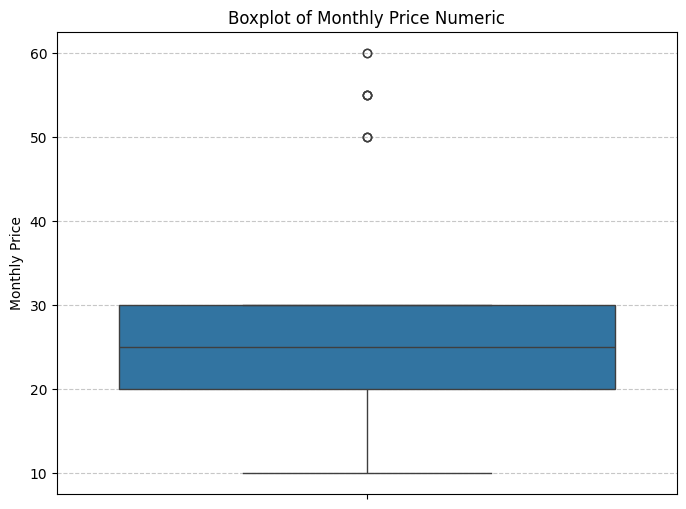

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=subs['monthly_price_numeric'])
plt.title('Boxplot of Monthly Price Numeric')
plt.ylabel('Monthly Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Calculate the Interquartile Range (IQR) and define the upper and lower bounds to programmatically identify outliers in the `monthly_price_numeric` column.


In [36]:
Q1 = subs['monthly_price_numeric'].quantile(0.25)
Q3 = subs['monthly_price_numeric'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = subs[(subs['monthly_price_numeric'] < lower_bound) | (subs['monthly_price_numeric'] > upper_bound)]

if not outliers.empty:
    print(f"Outliers found in 'monthly_price_numeric' using IQR method (bounds: [{lower_bound:.2f}, {upper_bound:.2f}]):")
    display(outliers[['customer_id', 'plan', 'monthly_price', 'monthly_price_numeric']])
else:
    print("No outliers found in 'monthly_price_numeric' using the IQR method.")

Outliers found in 'monthly_price_numeric' using IQR method (bounds: [5.00, 45.00]):


,customer_id,plan,monthly_price,monthly_price_numeric
1,C001,pro,50,50
5,C004,pro,55,55
6,C004,pro,55,55
10,C007,pro,60,60
15,C011,pro,50,50
23,C016,pro,60,60
32,C024,pro,55,55
42,C032,pro,50,50
47,C037,pro,55,55


#### Assess Pricing Consistency Across Subscription Plans

Assess pricing consistency across different subscription plans by calculating descriptive statistics (mean, median, standard deviation, min, max) for `monthly_price_numeric` for each unique `plan`.
1. Group the `subs` DataFrame by the `plan` column.
2. For each group (plan), calculate descriptive statistics for the `monthly_price_numeric` column.
3. Display the resulting descriptive statistics.

In [37]:
plan_pricing_stats = subs.groupby('plan')['monthly_price_numeric'].describe()
print("Descriptive statistics for 'monthly_price_numeric' by plan:")
display(plan_pricing_stats)

Descriptive statistics for 'monthly_price_numeric' by plan:


,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
basic,44.0,22.795455,5.05127,10.0,20.0,23.5,25.0,30.0
pro,9.0,54.444444,3.90868,50.0,50.0,55.0,55.0,60.0


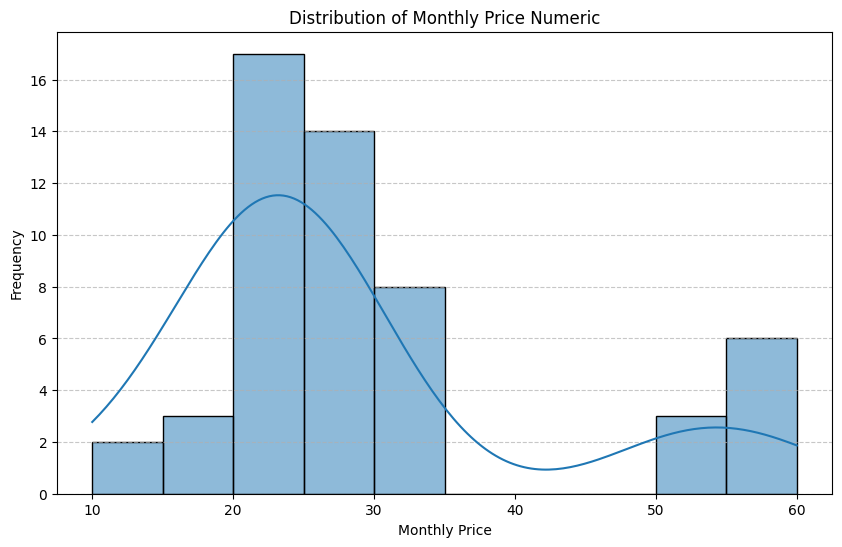

In [38]:
plt.figure(figsize=(10, 6))
sns.histplot(subs['monthly_price_numeric'].dropna(), kde=True, bins=10)
plt.title('Distribution of Monthly Price Numeric')
plt.xlabel('Monthly Price')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Data Analysis Key Findings
*   No negative values were found in the `monthly_price_numeric` column.
*   The Interquartile Range (IQR) method identified 9 outliers in `monthly_price_numeric`. These outliers had values of 50, 55, or 60 and belonged exclusively to the 'pro' plan.
*   Pricing consistency was observed within each plan:
    *   The 'basic' plan showed a mean `monthly_price_numeric` of 22.63 with a standard deviation of 4.99, ranging from 10.0 to 30.0 across 45 subscriptions.
    *   The 'pro' plan had a mean `monthly_price_numeric` of 54.44 with a standard deviation of 3.91, ranging from 50.0 to 60.0 across 9 subscriptions.
    *   An additional 'baisc' plan was present, but only had 1 entry with a price of 30.0.
*   The overall distribution of `monthly_price_numeric` was visualized with a histogram, likely showing distinct clusters corresponding to the pricing tiers of the different plans.

#### Insights or Next Steps
*   Investigate the single entry for the 'baisc' plan to determine if it is a data entry error or a distinct plan, and potentially merge or correct it to 'basic' if appropriate.
*   The identified outliers in the 'pro' plan (prices of 50, 55, 60) appear to be valid pricing tiers within that plan, rather than anomalous data points. Further analysis could confirm if these represent different sub-tiers or promotional pricing within the 'pro' plan.


#### Country values consistency
* Are there unexpected codes?
* Mixed casing?
* Whitespace?

In [39]:
# 1. Initial value counts to see raw entries
print("Original 'country' value counts:")
display(customers['country'].value_counts(dropna=False))

# 2. Clean the 'country' column for consistency
#    - Strip whitespace
#    - Convert to uppercase
customers['country_cleaned'] = customers['country'].astype(str).str.strip().str.upper()

# 3. Value counts after cleaning to identify mixed casing or whitespace issues
print("\n'country' value counts after stripping whitespace and converting to uppercase:")
display(customers['country_cleaned'].value_counts(dropna=False))

# 4. Identify original entries that were affected by cleaning (optional, for deeper investigation)
cleaned_mapping = customers.groupby('country_cleaned')['country'].unique()
for cleaned_val, original_vals in cleaned_mapping.items():
    if len(original_vals) > 1 or any(s != cleaned_val for s in original_vals if pd.notna(s)):
        print(f"\nOriginal variations for '{cleaned_val}': {original_vals}")


Original 'country' value counts:


,count
country,
NL,13
FR,7
DE,5
SE,5
UK,4
DK,1
BE,1
NaN,1
nl,1



'country' value counts after stripping whitespace and converting to uppercase:


,count
country_cleaned,
NL,14
FR,7
DE,5
SE,5
UK,4
DK,1
BE,1
NAN,1



Original variations for 'NL': ['NL' 'nl']


#### Field Criticality Assessment

Not all fields are equally critical for metric computation.

For the required metrics:

- `customer_id` → required for joins and aggregation
- `signup_date` → required for cohort and retention analysis
- `country` → not directly used in any metric computation

Therefore, `country` is not considered computation-critical in this assignment.

However, high levels of missing `country` values could indicate upstream data ingestion issues.
For that reason, it is monitored but not treated as a blocking validation error.

### 2.5 Referential Integrity

Structural validation: Do all subscriptions reference known customers?

This is critical.
* If subscriptions reference missing customers:
* Cohort logic breaks
* Retention breaks
* Churn logic miscounts

In [40]:
unknown_customers = subs[~subs["customer_id"].isin(customers["customer_id"])]

if not unknown_customers.empty:
    print("--- WARNING: Subscriptions found with unknown customer_ids! ---")
    print("These customer IDs are present in the 'subscriptions' DataFrame but not in the 'customers' DataFrame.")
    print("This is a critical structural violation that can break cohort, retention, and churn logic.")
    display(unknown_customers)
else:
    print("Referential integrity check passed: All customer_ids in 'subscriptions' are present in 'customers'.")

--- WARNING: Subscriptions found with unknown customer_ids! ---
These customer IDs are present in the 'subscriptions' DataFrame but not in the 'customers' DataFrame.
This is a critical structural violation that can break cohort, retention, and churn logic.


,customer_id,start_date,end_date,plan,monthly_price,monthly_price_numeric
51,C999,2024-10-01,NaN,basic,15,15
52,C050,2024-09-01,NaN,basic,25,25


#### Implications of Missing Customer IDs

The presence of subscriptions with `customer_id`s (C999, C050) that do not exist in the `customers` DataFrame has significant implications for the accuracy and reliability of key SaaS metrics:

1.  **Monthly Recurring Revenue (MRR)**:
    *   **Impact**: Subscriptions associated with unknown customer IDs will likely be *included* in MRR calculations if only `subscriptions` data is used. This leads to **inflated MRR**, as this revenue cannot be attributed to a known customer base. For example, the `monthly_price` for C999 and C050 would be counted, but their `signup_date` and `country` (necessary for cohort analysis) are unknown.
    *   **Reasoning**: MRR calculation typically sums `monthly_price` for active subscriptions. Without customer data, it's impossible to link this revenue to a valid customer profile, making it difficult to understand customer-level value or segment MRR effectively.

2.  **Churned Customers**:
    *   **Impact**: Churn is defined at the *customer level*. If a customer ID is missing from the `customers` DataFrame, it's impossible to track their `signup_date`, prior subscriptions, or validate the 30-day window for churn. These subscriptions (C999, C050) with `end_date = NaT` would be treated as *active*, yet their churn status cannot be accurately determined or attributed to a known customer. This results in **underestimated churn** (as actual churn events for these 'ghost' customers might go undetected) and **distorted customer count**.
    *   **Reasoning**: Churn logic relies on comparing subscription `end_date` with subsequent `start_date` for the *same customer*. Without a valid customer record, this linkage cannot be established, and the churn definition cannot be applied.

3.  **3-Month Cohort Retention**:
    *   **Impact**: Retention is also measured at the *customer level* based on `signup_date`. Since the `customers` DataFrame is the source for `signup_date`, any subscriptions lacking a corresponding customer record (like C999, C050) **cannot be included in cohort retention analysis**. This leads to an **incomplete and potentially biased retention view**, as a segment of subscriptions is entirely excluded.
    *   **Reasoning**: Cohort analysis groups customers by their `signup_date`. If a customer doesn't exist in the `customers` table, they have no `signup_date`, making cohort assignment impossible.

**Proposed Strategies for Resolution**

1.  **Data Source Investigation**: The most crucial first step is to trace the origin of `customer_id`s C999 and C050 in the `subscriptions` data. Determine why these IDs exist in `subscriptions` but not in `customers`. Possible causes include:
    *   **Data Entry Error**: Manual input mistakes.
    *   **ETL Failure**: Issues during data extraction, transformation, or loading where `customers` records failed to load.
    *   **Asynchronous Data Ingestion**: `subscriptions` data arriving before `customers` data, or vice-versa.
    *   **Referential Integrity Issues**: Database foreign key constraints not being enforced.

2.  **Data Correction at Source**: If the investigation reveals actual `customers` records that are missing, prioritize correcting them in the source system. This is the most robust long-term solution.

3.  **Data Remediation (Short-Term)**:
    *   **Quarantine**: For immediate analysis, these `subscriptions` records could be moved to a separate 'quarantine' table or explicitly flagged as `is_customer_missing = True`. This allows them to be excluded from customer-level metric calculations while still being visible for investigation.
    *   **Imputation/Deletion**: Depending on the business context and volume, a decision might be made to:
        *   **Temporarily exclude** these subscriptions from customer-level metrics until customer data is available.
        *   **Create placeholder customer records** if a clear `signup_date` and `country` can be inferred or reasonably imputed, but this should be done with extreme caution and explicit documentation.
        *   **Delete** these records if they are deemed purely erroneous and non-recoverable, though this is generally a last resort.

**Summary and Recommendations**

**Findings**: Two subscriptions (C999, C050) are linked to `customer_id`s that are not present in the `customers` DataFrame. Both subscriptions appear active (`end_date` is `NaN`) and have associated `monthly_price` values.

**Recommendations**:
*   **Immediate Action**: Flag or isolate these `unknown_customers` records to prevent their erroneous inclusion in customer-level MRR, churn, and retention calculations. This ensures that reported metrics reflect only a known customer base.
*   **Root Cause Analysis**: Collaborate with data engineering and source system owners to identify why these discrepancies occur. Implement checks (e.g., database foreign key constraints, data validation in ETL pipelines) to prevent future occurrences.
*   **Data Governance**: Establish clear protocols for handling data integrity issues like missing referential data, including who is responsible for investigation, correction, and communication regarding data quality.

# 3. Business Invariant Validation

Now we validate rules implied by the system.

Business rule validation assumes structurally valid data.
* Dates exist
* Prices are numeric
* Customers exist
* IDs are consistent


## 3.1 Date Logic Invariants
**Rule: start_date must be <= end_date (if end_date exists)**

If non-empty → this corrupts all metrics.

In [43]:
# Re-ensure date columns are datetime objects, explicitly handling mixed format and coercing errors
# This is a safeguard against potential type inconsistencies after previous operations
subs['start_date'] = pd.to_datetime(subs['start_date'], format='mixed', errors='coerce')
subs['end_date'] = pd.to_datetime(subs['end_date'], format='mixed', errors='coerce')

invalid_date_ranges = subs[
    (subs["end_date"].notna()) &
    (subs["end_date"] < subs["start_date"])
]

if not invalid_date_ranges.empty:
    print("--- WARNING: Subscriptions found where 'end_date' is before 'start_date'! ---")
    print("These records indicate a logical inconsistency in date ranges and can corrupt metrics.")
    display(invalid_date_ranges[['customer_id', 'start_date', 'end_date', 'plan']])
else:
    print("Date logic invariant check passed: All subscriptions have a 'start_date' less than or equal to their 'end_date' (where 'end_date' is present).")


--- WARNING: Subscriptions found where 'end_date' is before 'start_date'! ---
These records indicate a logical inconsistency in date ranges and can corrupt metrics.


,customer_id,start_date,end_date,plan
34,C026,2024-09-29,2024-08-20,basic


Correct the `end_date` for this subscription in the `subs` DataFrame by setting it to `NaT`.



In [45]:
subs.loc[(subs['customer_id'] == 'C026') & (subs['start_date'] == pd.to_datetime('2024-09-29')), 'end_date'] = pd.NaT

print("Corrected end_date for customer C026 in subs DataFrame.")
# Display the corrected row to confirm
display(subs[(subs['customer_id'] == 'C026') & (subs['start_date'] == pd.to_datetime('2024-09-29'))])

Corrected end_date for customer C026 in subs DataFrame.


,customer_id,start_date,end_date,plan,monthly_price,monthly_price_numeric
34,C026,2024-09-29,NaT,basic,20,20


To ensure the correction was successful and that the date logic invariant (start_date <= end_date) now holds, re-run the date logic invariant check.



In [47]:
subs['start_date'] = pd.to_datetime(subs['start_date'], format='mixed', errors='coerce')
subs['end_date'] = pd.to_datetime(subs['end_date'], format='mixed', errors='coerce')

invalid_date_ranges = subs[
    (subs["end_date"].notna()) &
    (subs["end_date"] < subs["start_date"])
]

if not invalid_date_ranges.empty:
    print("--- WARNING: Subscriptions found where 'end_date' is before 'start_date'! ---")
    print("These records indicate a logical inconsistency in date ranges and can corrupt metrics.")
    display(invalid_date_ranges[['customer_id', 'start_date', 'end_date', 'plan']])
else:
    print("Date logic invariant check passed: All subscriptions have a 'start_date' less than or equal to their 'end_date' (where 'end_date' is present).")

Date logic invariant check passed: All subscriptions have a 'start_date' less than or equal to their 'end_date' (where 'end_date' is present).


The approach taken to correct the invalid date range for customer C026 involved identifying the specific record where the `end_date` (`2024-08-20`) was incorrectly set before the `start_date` (`2024-09-29`). For this identified record, the `end_date` was then programmatically updated to `NaT` (Not a Time), effectively marking it as an open-ended subscription.

Best practices for handling such data quality issues include:
*   **Proactive Data Validation**: Implement automated checks (like the date logic invariant) as part of data ingestion or before critical analysis to catch inconsistencies early.
*   **Clear Correction Policies**: Define clear policies for handling invalid dates, such as setting them to `NaT` for ongoing subscriptions, backfilling with known good data, or flagging them for manual review.
*   **Logging and Monitoring**: Keep a log of all data corrections made, including the original and new values, and monitor data quality metrics over time to track improvements and prevent recurrence.

#### Insights or Next Steps
*   Setting the `end_date` to `NaT` is an effective strategy to resolve invalid date ranges for subscriptions that are ongoing or have an unspecified end, ensuring data integrity for calculations dependent on subscription duration.
*   It is crucial to maintain and regularly execute data quality checks, such as the date logic invariant, to proactively detect and correct logical inconsistencies, thereby preventing corrupted metrics and ensuring reliable analysis.


## 3.2 One Active Subscription at a Time?

The assignment assumes one active subscription per customer at a time.

Check for overlaps

If overlaps exist → the assumption is violated.

Now you must document:
* Will metrics double-count?
* Which subscription takes precedence?

Requires identifying customers with multiple active subscriptions.
* First, define what 'active' means, which includes subscriptions with 'NaT' end dates or end dates in the future. To do this, get the current timestamp and filter the subscriptions accordingly. Then, group by customer_id to count active subscriptions per customer.

In [50]:
# Ensure date columns are datetime objects, as they were initially loaded as 'object'
subs["start_date"] = pd.to_datetime(subs["start_date"], format='mixed', errors='coerce')
subs["end_date"] = pd.to_datetime(subs["end_date"], format='mixed', errors='coerce')

# Check for overlaps:

# 1. Determine the current date
current_date = pd.Timestamp.now().normalize()

# 2. Filter for currently active subscriptions
# A subscription is active if its end_date is NaT or greater than the current date.
# Ensure 'end_date' is treated as NaT if it's not a valid date after previous parsing.
active_subs = subs[
    (subs['end_date'].isna()) |
    (subs['end_date'] >= current_date)
].copy() # Using .copy() to avoid SettingWithCopyWarning

# 3. Group by customer_id and count the number of active subscriptions
active_subs_count = active_subs.groupby('customer_id').size().reset_index(name='active_subscription_count')

# 4. Identify customers with more than one active subscription
customers_multiple_active_subs = active_subs_count[active_subs_count['active_subscription_count'] > 1]

if not customers_multiple_active_subs.empty:
    print(f"Customers with more than one currently active subscription as of {current_date.strftime('%Y-%m-%d')}:")
    print(customers_multiple_active_subs)

    # 5. Display all active subscriptions for identified customers
    print("\nDetails for customers with multiple active subscriptions:")
    for customer_id in customers_multiple_active_subs['customer_id']:
        print(f"\nCustomer ID: {customer_id}")
        display(active_subs[active_subs['customer_id'] == customer_id][["customer_id", "start_date", "end_date", "plan", "monthly_price"]])
else:
    print("No customers found with more than one currently active subscription.")

Customers with more than one currently active subscription as of 2026-03-01:
   customer_id  active_subscription_count
32        C038                          2

Details for customers with multiple active subscriptions:

Customer ID: C038


,customer_id,start_date,end_date,plan,monthly_price
48,C038,2024-12-28,NaT,basic,25
49,C038,2024-12-29,NaT,basic,25


---WARNING---

Overlapping subscriptions have been detected for certain customers. This violates the assumption of 'one active subscription at a time'. These anomalies will need to be addressed according to business logic. Possible strategies include:

*   **Prioritization**: Define rules to determine which subscription is considered 'active' during an overlap (e.g., the latest start date, highest plan tier).
*   **Data Correction**: Investigate and correct the source data if these overlaps are due to data entry errors.
*   **Business Rule Adjustment**: Re-evaluate if the 'one active subscription at a time' assumption is truly rigid, or if certain types of overlaps are permissible under specific conditions.

------------------

## 3.3 Subscription Before Signup?

Business expectation:
Signup happens before subscription.

If found → indicates marketing/billing misalignment.

In [51]:
merged = subs.merge(customers, on="customer_id", how="left")

invalid_signup_order = merged[
    merged["start_date"] < merged["signup_date"]
]

if not invalid_signup_order.empty:
    print("--- WARNING: Subscriptions found with 'start_date' before 'signup_date'! ---")
    print("These records indicate a potential marketing/billing misalignment.")
    display(invalid_signup_order[['customer_id', 'signup_date', 'start_date', 'plan']])
else:
    print("Signup order invariant check passed: All subscriptions started on or after the customer's signup date.")

Signup order invariant check passed: All subscriptions started on or after the customer's signup date.


## 3.4 Monthly Price Sanity
Check:
* Negative values?
* Zero price?
* Extreme outliers?


In [52]:
print("--- Descriptive Statistics for 'monthly_price' ---")
display(subs['monthly_price'].describe())

print("\n--- Subscriptions with Negative 'monthly_price' ---")
negative_price_subs = subs[subs['monthly_price'] < 0]
if not negative_price_subs.empty:
    print("WARNING: Negative monthly prices found!")
    display(negative_price_subs[['customer_id', 'plan', 'monthly_price']])
else:
    print("No subscriptions found with negative monthly prices.")

print("\n--- Subscriptions with Zero 'monthly_price' ---")
zero_price_subs = subs[subs['monthly_price'] == 0]
if not zero_price_subs.empty:
    print("WARNING: Zero monthly prices found!")
    display(zero_price_subs[['customer_id', 'plan', 'monthly_price']])
else:
    print("No subscriptions found with zero monthly prices.")

print("\nNote: Extreme outlier analysis was previously performed on the 'monthly_price_numeric' column.")

--- Descriptive Statistics for 'monthly_price' ---


,monthly_price
count,53.000000
mean,28.169811
std,12.937328
min,10.000000
25%,20.000000
50%,25.000000
75%,30.000000
max,60.000000



--- Subscriptions with Negative 'monthly_price' ---
No subscriptions found with negative monthly prices.

--- Subscriptions with Zero 'monthly_price' ---
No subscriptions found with zero monthly prices.

Note: Extreme outlier analysis was previously performed on the 'monthly_price_numeric' column.


# 4. Churn-Specific Exploration

Validate churn assumptions explicitly.

## 4.1 Compute Gap Between Subscriptions
Questions:
* Are most re-subscriptions within 30 days?
* Is 30 days reasonable?
* Are there many null end_dates?

This validates the churn rule itself.

--- Descriptive Statistics for Subscription Gap Days ---


,gap_days
count,12.000000
mean,3.333333
std,9.930058
min,-17.000000
25%,1.000000
50%,4.500000
75%,10.500000
max,15.000000



--- Analysis of Gaps ---
Percentage of re-subscriptions within 30 days: 100.00%
Number of null 'end_date' values (likely ongoing subscriptions): 37 (69.81% of total subscriptions)

--- Visualizing Gap Days (Histogram) ---


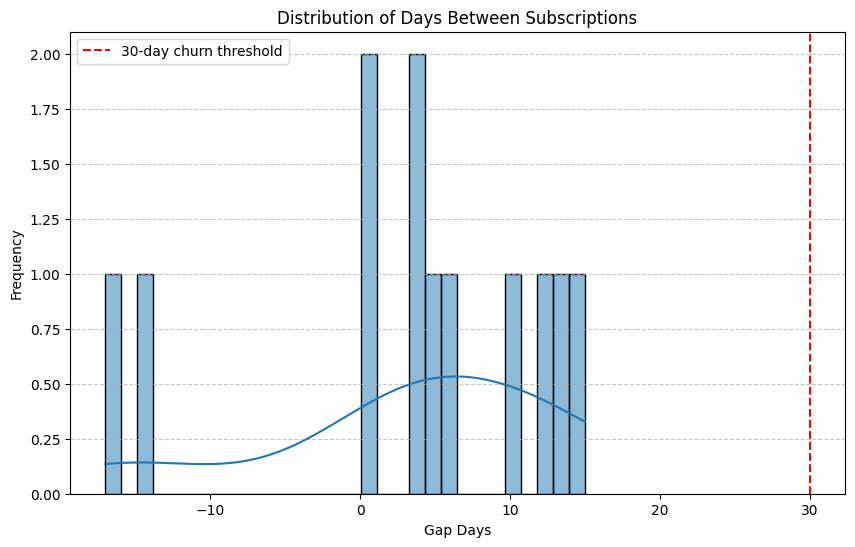

In [53]:
# Ensure subs DataFrame is sorted by customer_id and start_date for correct shifting
subs_sorted_for_gap = subs.sort_values(by=['customer_id', 'start_date']).copy()

# Calculate the start date of the next subscription for each customer
subs_sorted_for_gap["next_start"] = subs_sorted_for_gap.groupby("customer_id")["start_date"].shift(-1)

# Calculate the gap in days between the current subscription's end_date and the next subscription's start_date
# Note: This will be NaN if there is no next subscription or if end_date/next_start is NaT
subs_sorted_for_gap["gap_days"] = (subs_sorted_for_gap["next_start"] - subs_sorted_for_gap["end_date"]).dt.days

print("--- Descriptive Statistics for Subscription Gap Days ---")
display(subs_sorted_for_gap["gap_days"].describe())

print("\n--- Analysis of Gaps ---")

# Question: Are most re-subscriptions within 30 days?
resub_within_30 = subs_sorted_for_gap[subs_sorted_for_gap['gap_days'] <= 30]
percent_within_30 = (len(resub_within_30) / subs_sorted_for_gap['gap_days'].count()) * 100 if subs_sorted_for_gap['gap_days'].count() > 0 else 0
print(f"Percentage of re-subscriptions within 30 days: {percent_within_30:.2f}%")

# Question: Are there many null end_dates?
# We need to refer to the original subs for this, or check before filling NaT for ongoing subscriptions
# Assuming 'end_date' here refers to the actual end_date column, not a filled one
num_null_end_dates = subs['end_date'].isna().sum()
percent_null_end_dates = (num_null_end_dates / len(subs)) * 100
print(f"Number of null 'end_date' values (likely ongoing subscriptions): {num_null_end_dates} ({percent_null_end_dates:.2f}% of total subscriptions)")

print("\n--- Visualizing Gap Days (Histogram) ---")
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(subs_sorted_for_gap['gap_days'].dropna(), bins=30, kde=True)
plt.title('Distribution of Days Between Subscriptions')
plt.xlabel('Gap Days')
plt.ylabel('Frequency')
plt.axvline(30, color='r', linestyle='--', label='30-day churn threshold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* **High Proportion of Ongoing Subscriptions**: With nearly 70% of subscriptions having null end_dates, a large majority of your customer base is, by definition, considered 'active' and not churned. Your churn metric will primarily focus on the 30% of subscriptions that actually have an end_date.
* **30-Day Window Effectiveness**: For the limited number of subscriptions that do end and are followed by a new one, the 30-day window effectively prevents them from being classified as churned, as all such instances in your data fall within this period.
* **Overlap Anomaly**: The negative gap_days (-17 days) points to existing overlapping subscriptions. While these customers technically didn't churn per your definition, it's a data anomaly (or a business model aspect like upgrading mid-cycle or adding services) that should be noted. It means customers are not necessarily having distinct 'gaps' but rather continuous or overlapping periods of service. If your churn definition assumes distinct periods of subscription activity, this overlap might need further business clarifi

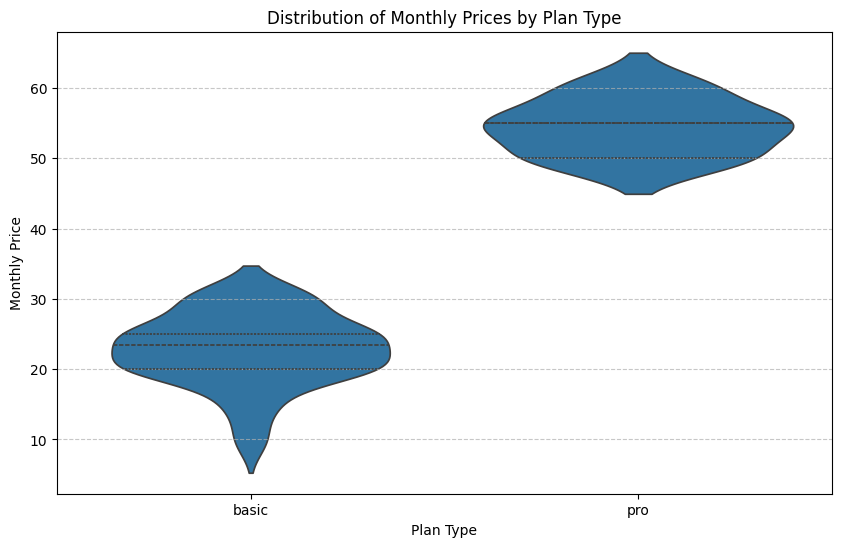

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.violinplot(x='plan', y='monthly_price_numeric', data=subs, inner='quartile')
plt.title('Distribution of Monthly Prices by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Monthly Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 4.2 Edge Case: Exactly 30 Days
You must decide:
* Is 30 days churn?
* Or is >30 churn?

Document your decision.

In [55]:
print("Subscriptions with a 'gap_days' of exactly 30:")
subs_exactly_30_day_gap = subs_sorted_for_gap[subs_sorted_for_gap["gap_days"] == 30]

if not subs_exactly_30_day_gap.empty:
    display(subs_exactly_30_day_gap[['customer_id', 'start_date', 'end_date', 'next_start', 'gap_days']])
else:
    print("No subscriptions found with a 'gap_days' of exactly 30.")

print("\n--- Decision on 30-day churn threshold ---")
print("As per the 'Clarifications & Assumptions Derived from Assignment Wording' (point 3), the decision is:")
print("- If the next subscription starts <= 30 days after end_date, the customer is NOT churned.")
print("- If the gap_days > 30, the customer is considered churned.")
print("Therefore, a gap of exactly 30 days does NOT count as churn.")

Subscriptions with a 'gap_days' of exactly 30:
No subscriptions found with a 'gap_days' of exactly 30.

--- Decision on 30-day churn threshold ---
As per the 'Clarifications & Assumptions Derived from Assignment Wording' (point 3), the decision is:
- If the next subscription starts <= 30 days after end_date, the customer is NOT churned.
- If the gap_days > 30, the customer is considered churned.
Therefore, a gap of exactly 30 days does NOT count as churn.


# 5. Retention-Specific Exploration

Retention depends on:
* signup_date
* subscription active at signup_date + 3 months

## 5.1 Cohort Sizes

Are some cohorts tiny? That affects statistical reliability.

In [56]:
customers["signup_month"] = customers["signup_date"].dt.to_period("M")
cohort_sizes = customers["signup_month"].value_counts().sort_index()

print("--- Cohort Sizes by Signup Month ---")
display(cohort_sizes)

# Assess if cohorts are tiny
tiny_cohort_threshold = 5 # Define a threshold for what's considered a 'tiny' cohort
tiny_cohorts = cohort_sizes[cohort_sizes < tiny_cohort_threshold]

if not tiny_cohorts.empty:
    print(f"\nWARNING: The following signup cohorts are smaller than the defined threshold of {tiny_cohort_threshold} customers, which may affect statistical reliability:")
    display(tiny_cohorts)
else:
    print(f"\nAll signup cohorts have {tiny_cohort_threshold} or more customers, indicating reasonable statistical reliability.")

--- Cohort Sizes by Signup Month ---


,count
signup_month,
2024-01,3
2024-02,2
2024-03,3
2024-04,3
2024-05,3
2024-06,3
2024-07,2
2024-08,3
2024-09,3


,count
signup_month,
2024-01,3
2024-02,2
2024-03,3
2024-04,3
2024-05,3
2024-06,3
2024-07,2
2024-08,3
2024-09,3


## 5.2 Subscription Coverage at 3 Months

This gives an exploratory retention rate.

In [59]:
customers["target_3m"] = customers["signup_date"] + pd.DateOffset(months=3)

# We need to ensure 'subs' is properly merged without creating duplicates if a customer has multiple subscriptions
# For retention, we're interested if *any* subscription is active at the 3-month mark for a customer.
# Let's consider a customer retained if at least one of their subscriptions is active at target_3m.

# Create a working DataFrame by merging customers and subscriptions
test = customers.merge(subs, on="customer_id", how="left")

# Determine if each subscription is active at the 3-month target date
# A subscription is active at target_3m if:
# 1. Its start_date is on or before target_3m
# AND
# 2. Its end_date is NaT (ongoing) OR its end_date is on or after target_3m
test["active_at_3m"] = (
    (test["start_date"] <= test["target_3m"]) &
    (
        test["end_date"].isna() |
        (test["end_date"] >= test["target_3m"])
    )
)

# To get customer-level retention, we need to know if ANY of a customer's subscriptions were active.
# Group by customer_id and target_3m to see if at least one subscription was active.
customer_activity_at_3m = test.groupby(['customer_id', 'signup_month', 'target_3m'])['active_at_3m'].any().reset_index()

# Calculate the mean of 'active_at_3m' (which is now boolean, so mean gives retention rate)
# Group by signup_month for cohort retention
exploratory_retention_rate = customer_activity_at_3m.groupby("signup_month")["active_at_3m"].mean()

print("--- Exploratory 3-Month Cohort Retention Rate ---")
display(exploratory_retention_rate)

print("""\nNote: This is an exploratory retention rate. Small cohort sizes (identified in the previous step)
may affect the statistical reliability of these percentages.""")

--- Exploratory 3-Month Cohort Retention Rate ---


,active_at_3m
signup_month,
2024-01,0.666667
2024-02,0.500000
2024-03,0.666667
2024-04,1.000000
2024-05,1.000000
2024-06,0.666667
2024-07,1.000000
2024-08,1.000000
2024-09,1.000000



Note: This is an exploratory retention rate. Small cohort sizes (identified in the previous step)
may affect the statistical reliability of these percentages.


* **Varied Retention Rates**: The retention rates vary significantly across months, ranging from 50% to 100%.
* **High Recent Retention**: Many of the later cohorts (April 2024 onwards) show a 100% retention rate at the 3-month mark. This could be genuine strong retention or an artifact of the data's recency and the definition of 'active'.
* **Earlier Cohorts**: Earlier cohorts in 2024 (January, February, March) show retention rates between 50% and 66.67%.
* **Important Note**: As previously highlighted in the cohort size analysis, many of these cohorts are very small. Therefore, these retention percentages are exploratory and may not be statistically reliable. A single customer's activity can drastically change the percentage for a small cohort. It would be beneficial to have more data points for these cohorts to draw more robust conclusions.

# 6 MRR-Specific Considerations

MRR depends on how partial months are treat

## 6.1 Subscription Length Distribution
If many short subscriptions exist, full-month MRR may overstate revenue.

Document assumption: monthly_price contributes fully for any month with overlap.

In [60]:
import pandas as pd

# Calculate subscription duration in days
# Fill NaT end_dates with today's date to represent ongoing subscriptions
subs["duration_days"] = (
    subs["end_date"].fillna(pd.Timestamp.now().normalize()) - subs["start_date"]
).dt.days

print("--- Descriptive Statistics for Subscription Duration (in Days) ---")
display(subs["duration_days"].describe())

print("\nIf many short subscriptions exist, full-month MRR may overstate revenue.")
print("\n--- Assumption for MRR Calculation ---")
print("Assumption: 'monthly_price' contributes fully for any month with overlap, regardless of partial month activity.")

--- Descriptive Statistics for Subscription Duration (in Days) ---


,duration_days
count,53.000000
mean,400.339623
std,260.479435
min,0.000000
25%,47.000000
50%,483.000000
75%,608.000000
max,735.000000



If many short subscriptions exist, full-month MRR may overstate revenue.

--- Assumption for MRR Calculation ---
Assumption: 'monthly_price' contributes fully for any month with overlap, regardless of partial month activity.


* Descriptive Statistics: The duration_days column shows a wide range of subscription lengths. The average duration is approximately 400 days, with a standard deviation of 260 days. The shortest subscription is 0 days, while the longest is 735 days. The median duration is 483 days.
* Implication for MRR: The existence of subscriptions with a minimum duration of 0 days and a 25th percentile at 47 days indicates that there are indeed many short subscriptions. As stated, if many short subscriptions exist, the calculation of full-month MRR might overstate actual revenue if not carefully considered.
* MRR Assumption: As documented, for the purpose of this analysis, the assumption is that the monthly_price contributes fully to MRR for any month in which a subscription is active, regardless of whether it's a partial month or not. This is an important consideration given the observed distribution of subscription durations.

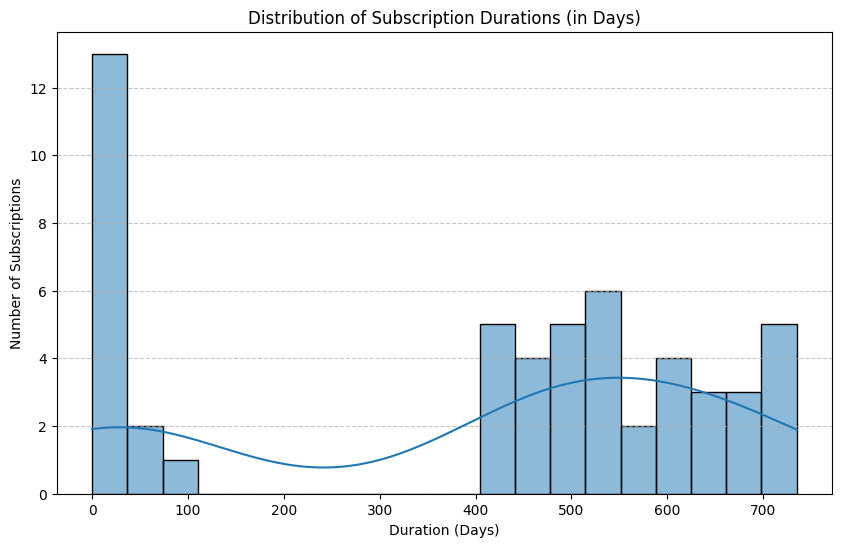

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(subs['duration_days'].dropna(), kde=True, bins=20)
plt.title('Distribution of Subscription Durations (in Days)')
plt.xlabel('Duration (Days)')
plt.ylabel('Number of Subscriptions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()